In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from IPython.display import display
import matplotlib.patheffects as pe

In [2]:
geo = pd.read_csv('/mnt/scratch/baburish/doublepulse/gnn/Analysis/data/geometry_clean.csv')
X = geo['dom_x']
Y = geo['dom_y']
Z = geo['dom_z']

In [4]:
connection = sqlite3.connect("/mnt/research/IceCube/lownutau/gemini/gemini_moreMC_sqlite/nue_train/nue_gemini_taupede_5TeV_lowerbound_skimmed_chunk_022855.000106_0000.db_train.db")
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = connection.cursor()
cursor.execute(sql_query)
output = cursor.fetchall()
print(output)

[('CleanedROIPulses',), ('truth',), ('reco',)]


In [5]:
df_truth = pd.read_sql_query("SELECT * FROM truth;", connection)
df_pulses = pd.read_sql_query("SELECT * FROM CleanedROIPulses;", connection)
df_reco = pd.read_sql_query("SELECT * FROM reco;", connection)
connection.close()

In [6]:
print(df_truth.columns)
print(df_pulses.columns)
print(df_reco.columns)

Index(['primary_energy', 'energy', 'position_x', 'position_y', 'position_z',
       'azimuth', 'zenith', 'pid', 'signal', 'sim_type', 'interaction_type',
       'run_id', 'subrun_id', 'event_id', 'subevent_id', 'inelasticity',
       'event_category', 'seed_string', 'tau_prod_vertex_x',
       'tau_prod_vertex_y', 'tau_prod_vertex_z', 'tau_prod_vertex_t',
       'tau_dec_vertex_x', 'tau_dec_vertex_y', 'tau_dec_vertex_z',
       'tau_dec_vertex_t', 'e_prod_vertex_x', 'e_prod_vertex_y',
       'e_prod_vertex_z', 'e_prod_vertex_t', 'mjd', 'TIntProbW', 'OneWeight',
       'Inelasticity_param_a', 'Inelasticity_param_b', 'MCPrimaryType',
       'MCPrimaryAzimuth', 'MCPrimaryEnergy', 'MCPrimaryZenith', 'Event',
       'SubEvent', 'IceScattering', 'IceAbsorption', 'DOMEfficiency',
       'IceAnisotropyScale', 'HoleIceForward_p0', 'HoleIceForward_p1',
       'MuonWeight', 'train_pass', 'event_no'],
      dtype='str')
Index(['charge', 'dom_time', 'dom_x', 'dom_y', 'dom_z', 'event_no'], dtype='st

In [9]:
print(df_truth['interaction_type'].head())
print(df_pulses['dom_time'].head())

0   -1.0
1   -1.0
2   -1.0
3   -1.0
4   -1.0
Name: interaction_type, dtype: float64
0    1830.0
1     595.0
2     621.0
3    1800.0
4     723.0
Name: dom_time, dtype: float64


In [7]:
len(df_pulses)
len(df_truth)

1384

In [8]:
df_truth.head()

,primary_energy,energy,position_x,position_y,position_z,azimuth,zenith,pid,signal,sim_type,...,SubEvent,IceScattering,IceAbsorption,DOMEfficiency,IceAnisotropyScale,HoleIceForward_p0,HoleIceForward_p1,MuonWeight,train_pass,event_no
0,5749.291615,5749.291615,1.065147e+03,7.310746e+02,1.947869e+03,0.345879,0.667777,-12.0,0.0,genie,...,0.0,0.950393,1.060321,1.001491,None,0.303307,-0.062119,None,1.0,1
1,5805.624254,5805.624254,-2.893688e+03,7.684919e+03,1.942711e+03,1.949196,1.353527,12.0,0.0,genie,...,0.0,0.945861,1.017830,0.994480,None,0.391354,-0.063297,None,1.0,2
2,6337.558013,6337.558013,5.383388e+06,1.316670e+05,-2.961705e+06,0.024462,2.073649,-12.0,0.0,genie,...,0.0,0.957505,1.009588,1.021576,None,0.514372,-0.116077,None,1.0,3
3,7502.362188,7502.362188,-8.291651e+03,1.505207e+04,1.924835e+03,2.087841,1.436242,12.0,0.0,genie,...,0.0,0.957505,1.009588,1.021576,None,0.514372,-0.116077,None,1.0,4
4,8274.635543,8274.635543,1.063583e+06,-1.599300e+06,-2.943069e+05,5.299136,1.722898,12.0,0.0,genie,...,0.0,0.997888,0.903043,1.065645,None,0.534671,-0.077184,None,1.0,6


In [9]:
df_pulses.head()

,charge,dom_time,dom_x,dom_y,dom_z,event_no
0,0.925,1830.0,-234.95,140.44,278.79,1
1,0.125,595.0,-234.95,140.44,261.77,1
2,0.675,621.0,-234.95,140.44,261.77,1
3,1.275,1800.0,-234.95,140.44,261.77,1
4,0.575,723.0,-234.95,140.44,244.75,1


In [10]:
grouped_piddf = df_truth.groupby('event_no').agg({
    'pid': lambda x: list(x),
}).reset_index()
grouped_piddf.rename(columns={
    'pid': 'pid',
}, inplace=True)

cols_to_convert = ['pid']

for col in cols_to_convert:
    grouped_piddf[col] = grouped_piddf[col].apply(lambda x: np.array(x))

grouped_df = df_pulses.groupby('event_no').agg({
    'charge': lambda x: list(x),
    'dom_x': lambda x: list(x),
    'dom_y': lambda x: list(x),
    'dom_z': lambda x: list(x),
    'dom_time': lambda x: list(x)
}).reset_index()

grouped_df.rename(columns={
    'charge': 'charge',
    'dom_x': 'dom_x',
    'dom_y': 'dom_y',
    'dom_z': 'dom_z',
    'dom_time': 'dom_time'
}, inplace=True)
cols_to_convert = ['charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time']

for col in cols_to_convert:
    grouped_df[col] = grouped_df[col].apply(lambda x: np.array(x))
df = pd.merge(grouped_df, grouped_piddf, on='event_no', how='inner')

print(grouped_df.columns)
print(grouped_piddf.columns)
print(df.columns)
print(len(df['event_no'],))
print(len(df['pid'],))

Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time'], dtype='str')
Index(['event_no', 'pid'], dtype='str')
Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time', 'pid'], dtype='str')
1384
1384


In [11]:
duplicates = df[df.duplicated(subset=['event_no'])]
print(duplicates)

Empty DataFrame
Columns: [event_no, charge, dom_x, dom_y, dom_z, dom_time, pid]
Index: []


In [12]:
print(len(df['event_no'],))
print(len(df['pid'],))

1384
1384


In [13]:
%matplotlib inline
def flatten_list_column(col):
    flat_list = []
    for item in col:
        if isinstance(item, list):
            flat_list.extend(item)
        else:
            flat_list.append(item)
    return flat_list
# dfrow = df.iloc[10]
dfrow = df.iloc[df['charge'].apply(sum).idxmax()]
print(df['charge'].apply(sum).idxmax())
print(df_truth.iloc[df['charge'].apply(sum).idxmax()])
# print(dfrow['pid'])
dom_x_flat = flatten_list_column(dfrow['dom_x'])
dom_y_flat = flatten_list_column(dfrow['dom_y'])
dom_z_flat = flatten_list_column(dfrow['dom_z'])
charge_flat = flatten_list_column(dfrow['charge'])

df_redpulses = pd.DataFrame({
    'dom_x': dom_x_flat,
    'dom_y': dom_y_flat,
    'dom_z': dom_z_flat,
    'charge': charge_flat,
    'dom_time': flatten_list_column(dfrow['dom_time'])
})



charge_per_dom = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()


251
primary_energy                  6937.976751
energy                          6937.976751
position_x                   4205598.679224
position_y                  -2633597.705112
position_z                  -2371350.196459
azimuth                            5.723798
zenith                             2.016613
pid                                    12.0
signal                                  0.0
sim_type                              genie
interaction_type                       -1.0
run_id                         2285500731.0
subrun_id                      4294967295.0
event_id                            70840.0
subevent_id                             0.0
inelasticity                            NaN
event_category                          5.0
seed_string                            15.0
tau_prod_vertex_x                      None
tau_prod_vertex_y                      None
tau_prod_vertex_z                      None
tau_prod_vertex_t                      None
tau_dec_vertex_x            

53691532
47964143

In [14]:
dom_count = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z']).size().reset_index(name='count')
dom_count = dom_count[dom_count['count'] > 1]
print(dom_count)

     dom_x   dom_y   dom_z  count
1  -492.43 -230.16  140.17      3
8  -413.46 -327.27  108.12      4
9  -413.46 -327.27  125.14      8
10 -413.46 -327.27  142.16      5
11 -413.46 -327.27  159.18     10
12 -413.46 -327.27  176.20      9
13 -413.46 -327.27  193.22      6
14 -413.46 -327.27  210.24      4
15 -413.46 -327.27  227.26      2
17 -368.93 -210.23   40.97      2
18 -368.93 -210.23   92.04      2
19 -368.93 -210.23  109.06      6
20 -368.93 -210.23  126.08     14
21 -368.93 -210.23  143.10     14
22 -368.93 -210.23  160.12     10
23 -368.93 -210.23  177.14      7
24 -368.93 -210.23  194.16      7
25 -368.93 -210.23  211.18      2
26 -368.93 -210.23  228.20      2
28 -334.80 -424.50   24.01      2
31 -334.80 -424.50  126.14      3
33 -334.80 -424.50  160.18      3
34 -334.80 -424.50  177.20      3
36 -334.80 -424.50  228.26      2
37 -324.39  -93.43  159.72      2
39 -290.66 -307.38   10.54      2
41 -290.66 -307.38   44.58      3
42 -290.66 -307.38   61.61      3
43 -290.66 -30

In [15]:
min(df_redpulses['dom_time']) - min(df_redpulses['dom_time'])

0.0

dom_x    -570.90
dom_y    -125.14
dom_z    -453.56
charge     21.10
Name: 3, dtype: float64


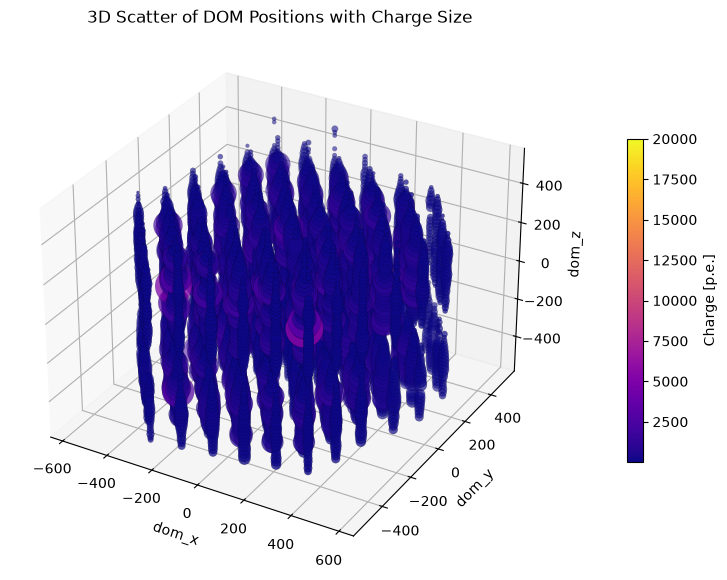

In [16]:
charge_per_dom = df_pulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()
charge_per_dom_row = charge_per_dom.iloc[3]
x, y, z, charge = charge_per_dom['dom_x'],charge_per_dom['dom_y'],charge_per_dom['dom_z'], charge_per_dom['charge']
print(charge_per_dom_row) 
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# im2 = ax.scatter(X, Y, Z, marker='o', s=1)
im = ax.scatter(x, y, z, s=np.sqrt(charge * 100), c=charge, cmap='plasma', edgecolors='k',linewidths=0.1, zorder=100, vmax=20000)
ax.set_xlabel('dom_x')
ax.set_ylabel('dom_y')
ax.set_zlabel('dom_z')
ax.set_title('3D Scatter of DOM Positions with Charge Size')

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Charge [p.e.]')

plt.show()

Running trials for 4
Running first for 4, -109.0, 1985.0


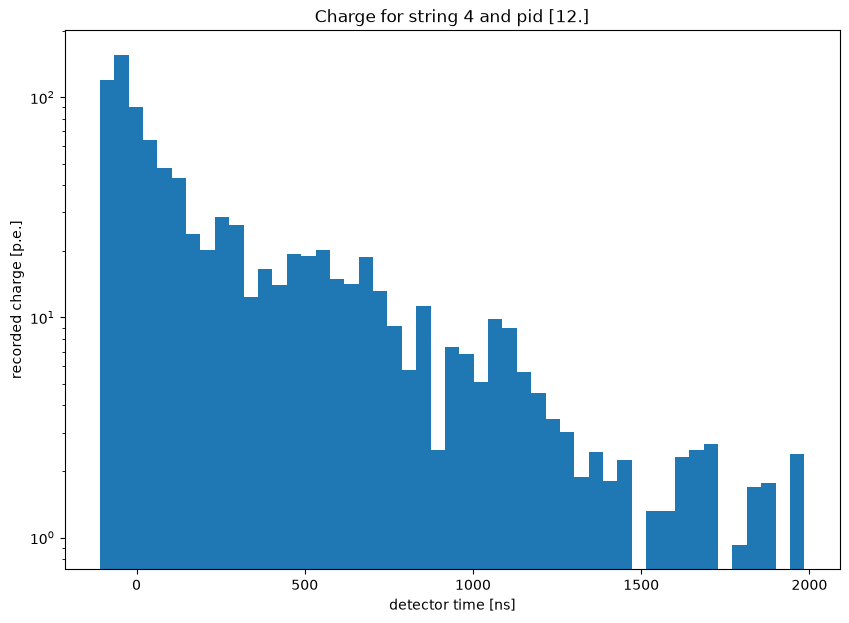

In [17]:
# print("n_doms", len(df_EventSeedPulses))
# for num in range(len(df)):
for num in range(4, 5):
    print(f'Running trials for {num}')
    dfrow = df.iloc[num]
    x = np.array(dfrow['dom_x'])
    y = np.array(dfrow['dom_y'])
    z = np.array(dfrow['dom_z'])
    charge = np.array(dfrow['charge'])
    time = np.array(dfrow['dom_time'])
    pid = np.array(dfrow['pid'])
    fig = plt.figure(figsize=(20, 10))
    ax = fig.add_subplot(131,projection='3d')
    if np.max(time)/2 > 2*np.min(time):
        print(f'Running first for {num}, {np.min(time)}, {np.max(time)}')
        im = ax.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        # linewidths=0.1,
                        zorder=1000,
                        vmax=np.max(time)/2)
    else:
        print(f'Running second for {num}, {np.min(time)}, {np.max(time)}')
        im = ax.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        # linewidths=0.1,
                        zorder=1000,
                        vmax=np.max(time))

    fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='time [ns]')
    ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
    ax.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
    ax.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
    ax.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)
    ax.set_title(f'Time Event view for event no {num} and pid {pid}')

    ax2 = fig.add_subplot(132, projection='3d')
    im = ax2.scatter(x, y, z, s=np.sqrt(charge * 100), c=charge, cmap='plasma', edgecolors='k', zorder=1000, vmax=np.max(charge))
    ax2.set_xlabel('dom_x')
    ax2.set_ylabel('dom_y')
    ax2.set_zlabel('dom_z')
    ax2.set_title(f'Charge Event view for event no {num} and pid {pid}')
    cbar = plt.colorbar(im, ax=ax2, shrink=0.6, pad=0.1)
    cbar.set_label('Charge [p.e.]')

    ax3 = fig.add_subplot(133,projection='3d')
    im2 = ax3.scatter(X, Y, Z, marker='o', s=1)
    if np.max(time)/2 > 2*np.min(time):
        im = ax3.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        zorder=1000,
                        vmax=np.max(time)/2)
    else:
        im = ax3.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        zorder=1000,
                        vmax=np.max(time))

    fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='time [ns]')
    ax3.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
    ax3.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
    ax3.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
    ax3.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)
    ax3.set_title(f'Event view for event no {num} and pid {pid}')

    # pdf_pages.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    min_time = min(dfrow['dom_time'])
    max_time = max(dfrow['dom_time'])
    time_bins = np.linspace(min_time, max_time, 50)
    fig = plt.figure(figsize=(10, 7))
    ax3 = fig.add_subplot(111)
    ax3.hist(dfrow['dom_time'], bins=time_bins, weights=dfrow['charge'])
    ax3.set_ylabel("recorded charge [p.e.]")
    ax3.set_xlabel("detector time [ns]")
    ax3.set_yscale('log')
    ax3.set_title(f"Charge for string {num} and pid {pid}")
    plt.show()
    plt.close(fig)

# pdf_pages.close()

## Goal 1: brightest string — charge vs hit time

A "string" is the set of DOMs sharing the same `(dom_x, dom_y)` — strings run vertically in `dom_z`, so grouping pulses by `(dom_x, dom_y)` identifies which string each hit belongs to. Builds on `df_redpulses` from the cell above (flattened pulses for the peak-charge event, `event_no=18`).

In [18]:
# Strings are identified by DOMs sharing the same (dom_x, dom_y); dom_z varies along a string.
charge_per_string = (df_redpulses
                      .groupby(['dom_x', 'dom_y'])['charge']
                      .sum()
                      .sort_values(ascending=False))

brightest_x, brightest_y = charge_per_string.index[0]
brightest_total_charge = charge_per_string.iloc[0]

string_pulses = (df_redpulses[(df_redpulses['dom_x'] == brightest_x) &
                               (df_redpulses['dom_y'] == brightest_y)]
                  .sort_values('dom_time')
                  .reset_index(drop=True))

print(f"event_no = {dfrow['event_no']}")
print(f"n_strings_hit = {len(charge_per_string)}")
print(f"brightest string: dom_x={brightest_x}, dom_y={brightest_y}, "
      f"total charge = {brightest_total_charge:.2f} p.e., "
      f"n_doms_on_string = {string_pulses['dom_z'].nunique()}, "
      f"n_pulses_on_string = {len(string_pulses)}")

string_pulses

event_no = 6
n_strings_hit = 10
brightest string: dom_x=-290.66, dom_y=-307.38, total charge = 5959.57 p.e., n_doms_on_string = 17, n_pulses_on_string = 471


,dom_x,dom_y,dom_z,charge,dom_time
0,-290.66,-307.38,129.57,7.275001,-119.0
1,-290.66,-307.38,129.57,3.475000,-116.0
2,-290.66,-307.38,129.57,5.075000,-115.0
3,-290.66,-307.38,129.57,1.775000,-107.0
4,-290.66,-307.38,129.57,37.924995,-89.0
...,...,...,...,...,...
466,-290.66,-307.38,129.57,20.375000,1909.0
467,-290.66,-307.38,129.57,14.375000,1940.0
468,-290.66,-307.38,146.59,2.125000,1944.0
469,-290.66,-307.38,129.57,12.925001,1959.0


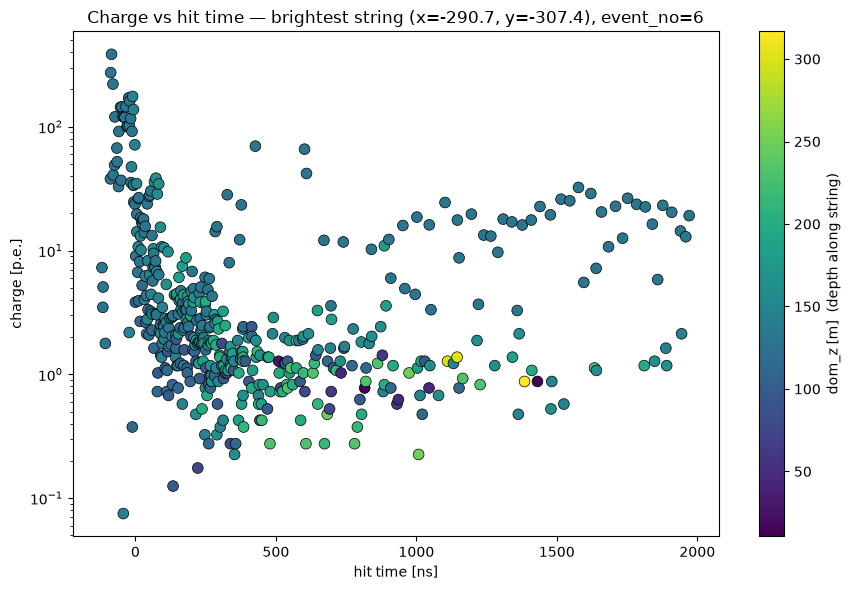

In [19]:
import matplotlib.colors as colors
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(string_pulses['dom_time'], string_pulses['charge'],
                 c=string_pulses['dom_z'], cmap='viridis',# norm=colors.LogNorm(),
                 s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('hit time [ns]')
ax.set_ylabel('charge [p.e.]')
ax.set_yscale('log')
ax.set_title(f"Charge vs hit time — brightest string "
             f"(x={brightest_x:.1f}, y={brightest_y:.1f}), event_no={dfrow['event_no']}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('dom_z [m]  (depth along string)')
plt.tight_layout()
plt.show()

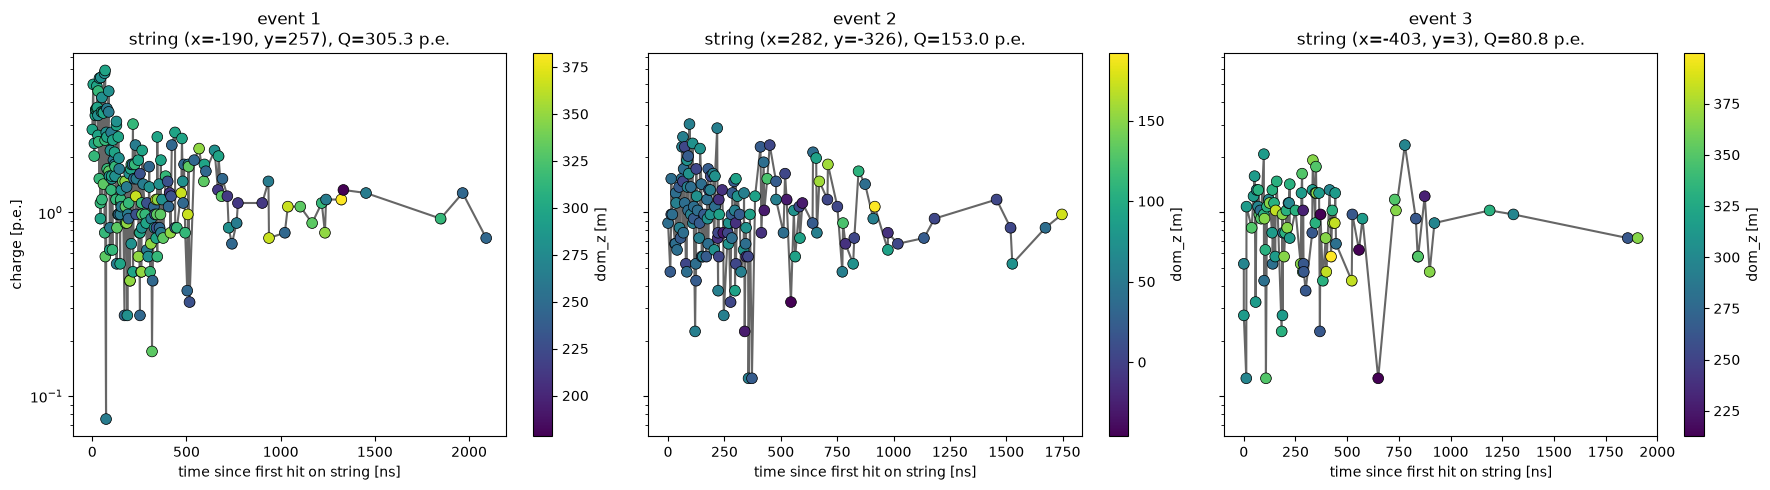

In [20]:
n_events = 3
charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

event_list = df['event_no'].iloc[:n_events].tolist()

def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()

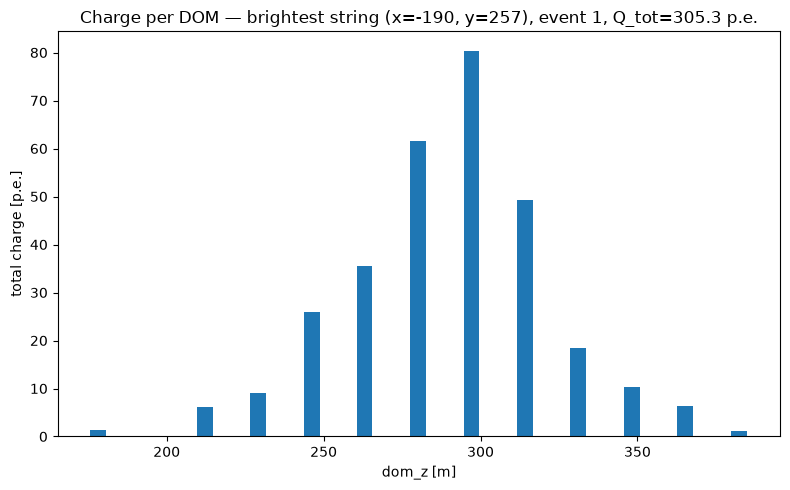

In [21]:
event_no = df['event_no'].iloc[0]  # <- set the event to analyze

string_pulses, bx, by, total_q = brightest_string_pulses(event_no)

charge_per_dom_on_string = (string_pulses
                             .groupby('dom_z')['charge']
                             .sum()
                             .sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(charge_per_dom_on_string.index, charge_per_dom_on_string.values, width=5)
ax.set_xlabel('dom_z [m]')
ax.set_ylabel('total charge [p.e.]')
ax.set_title(f'Charge per DOM — brightest string (x={bx:.0f}, y={by:.0f}), event {event_no}, Q_tot={total_q:.1f} p.e.')
plt.tight_layout()
plt.show()

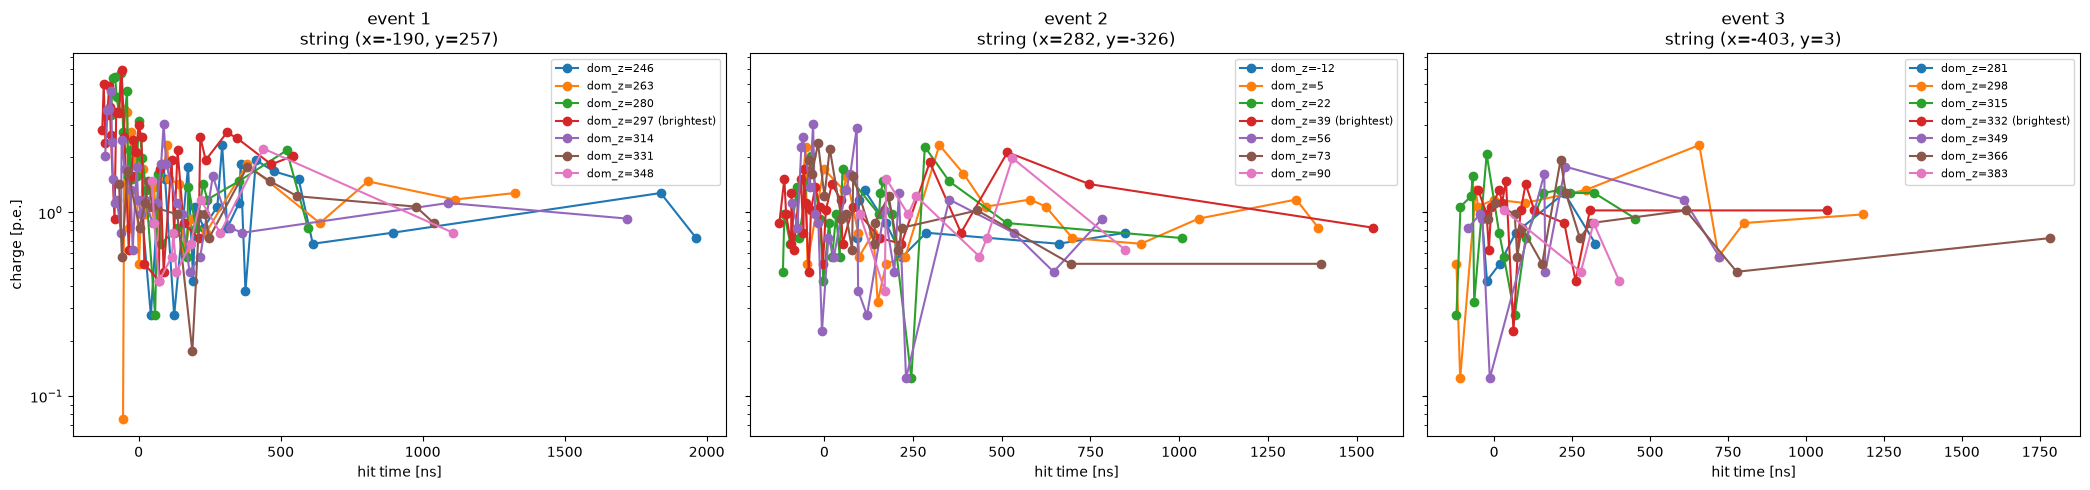

In [22]:
n_events = 3
n_side = 3  # doms on each side of the brightest dom

event_list = df['event_no'].iloc[:n_events].tolist()

def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

def neighbor_doms(string_pulses, n_side=3):
    charge_per_dom = string_pulses.groupby('dom_z')['charge'].sum().sort_index()
    dom_zs = charge_per_dom.index.to_numpy()
    brightest_dom_z = charge_per_dom.idxmax()
    center_idx = np.where(dom_zs == brightest_dom_z)[0][0]
    lo = max(center_idx - n_side, 0)
    hi = min(center_idx + n_side + 1, len(dom_zs))
    return dom_zs[lo:hi], brightest_dom_z

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 5), sharey=True)
if n == 1:
    axes = [axes]
colors_cycle = plt.cm.tab10.colors

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)
    selected_doms, brightest_dom_z = neighbor_doms(string_pulses, n_side=n_side)

    for i, z in enumerate(selected_doms):
        dom_hits = string_pulses[string_pulses['dom_z'] == z].sort_values('dom_time')
        label = f"dom_z={z:.0f}" + (" (brightest)" if z == brightest_dom_z else "")
        ax.plot(dom_hits['dom_time'], dom_hits['charge'], '-o',
                color=colors_cycle[i % len(colors_cycle)], label=label)

    ax.set_xlabel('hit time [ns]')
    ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f})")
    ax.legend(fontsize=8)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()

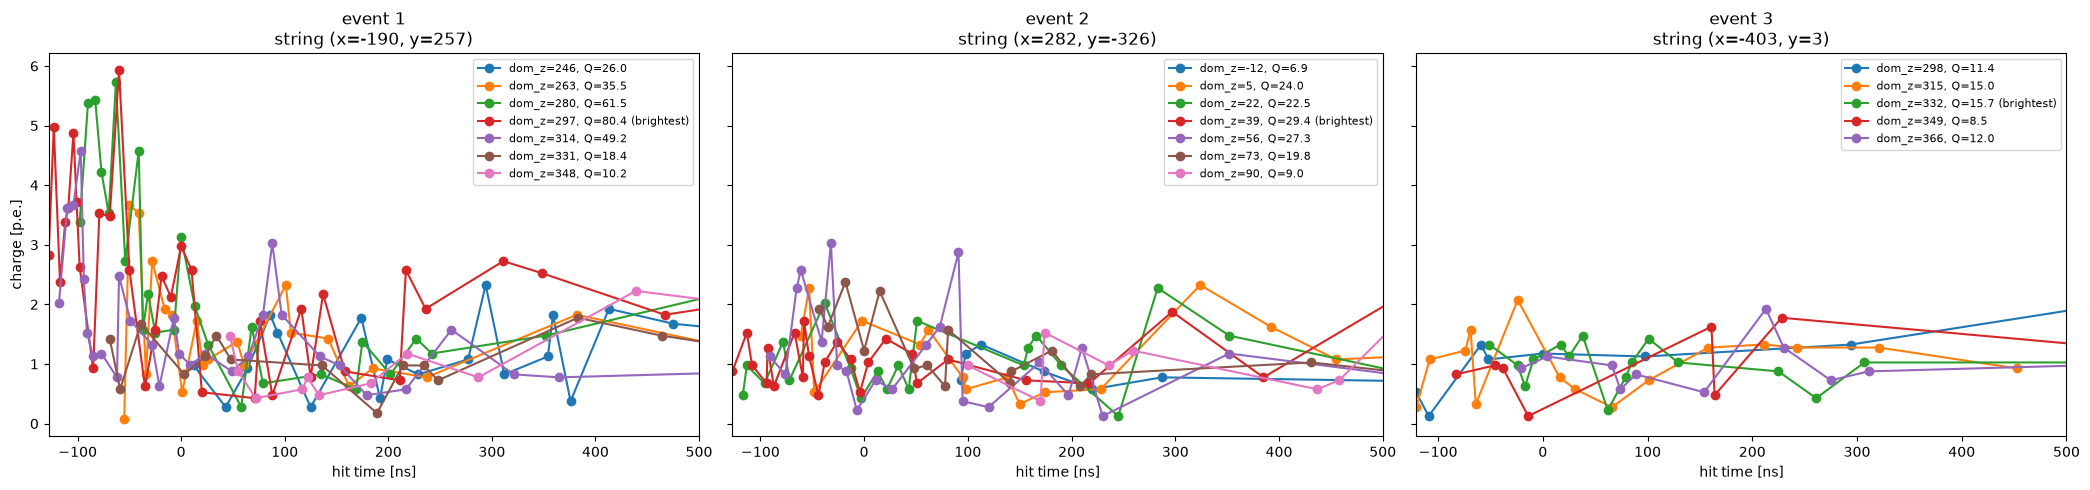

In [23]:
n_events = 3
n_side = 3 
charge_threshold = 5 

event_list = df['event_no'].iloc[:n_events].tolist()

def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

def neighbor_doms(string_pulses, n_side=3):
    charge_per_dom = string_pulses.groupby('dom_z')['charge'].sum().sort_index()
    dom_zs = charge_per_dom.index.to_numpy()
    brightest_dom_z = charge_per_dom.idxmax()
    center_idx = np.where(dom_zs == brightest_dom_z)[0][0]
    lo = max(center_idx - n_side, 0)
    hi = min(center_idx + n_side + 1, len(dom_zs))
    return dom_zs[lo:hi], brightest_dom_z, charge_per_dom

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 5), sharey=True)
if n == 1:
    axes = [axes]
colors_cycle = plt.cm.tab10.colors

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)
    selected_doms, brightest_dom_z, charge_per_dom = neighbor_doms(string_pulses, n_side=n_side)
    selected_doms = [z for z in selected_doms if charge_per_dom[z] > charge_threshold]

    for i, z in enumerate(selected_doms):
        dom_hits = string_pulses[string_pulses['dom_z'] == z].sort_values('dom_time')
        label = f"dom_z={z:.0f}, Q={charge_per_dom[z]:.1f}" + (" (brightest)" if z == brightest_dom_z else "")
        ax.plot(dom_hits['dom_time'], dom_hits['charge'], '-o',
                color=colors_cycle[i % len(colors_cycle)], label=label)

    ax.set_xlabel('hit time [ns]')
    # ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f})")
    ax.legend(fontsize=8)
    ax.set_xlim(min(string_pulses['dom_time']), 500)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()

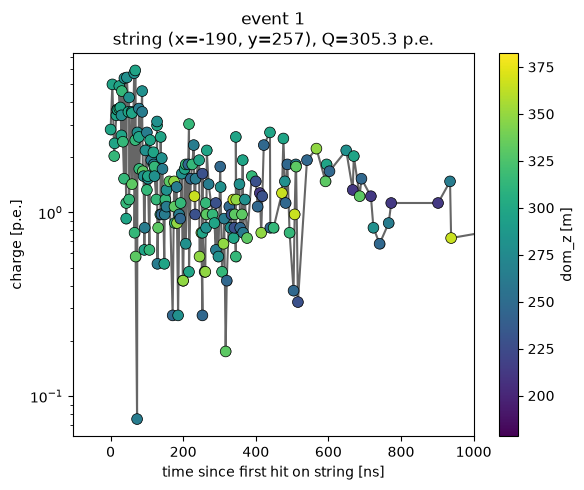

In [24]:
n_events = 1
charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

event_list = df['event_no'].iloc[:n_events].tolist()

def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=1000)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()

selected 2 events with brightest-string charge > 1000 p.e.: [10, 27]


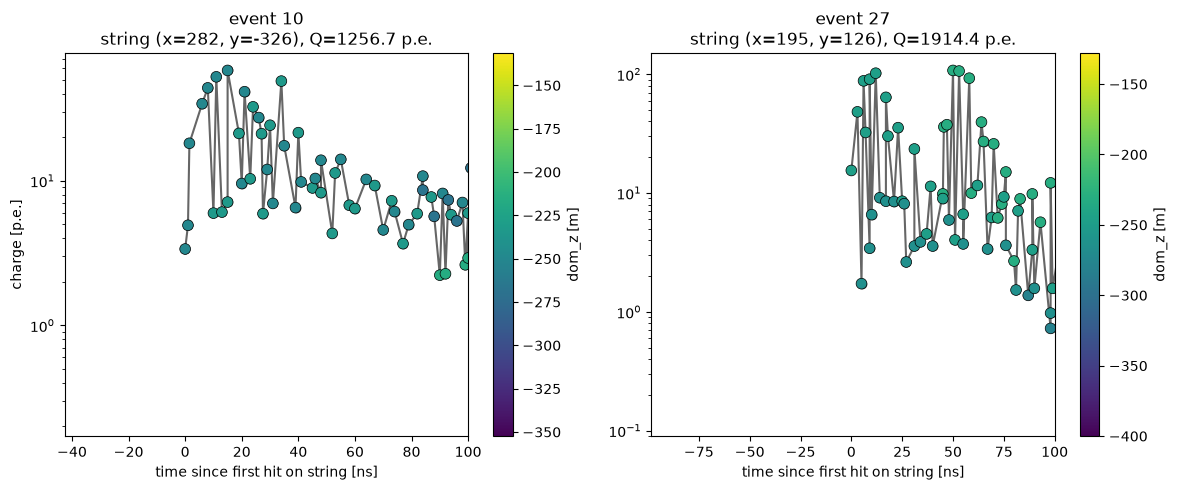

In [27]:
def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n_events = 2
charge_threshold_event = 1000

event_list = []
for ev in df['event_no']:
    _, _, _, total_q = brightest_string_pulses(ev)
    if total_q > charge_threshold_event:
        event_list.append(ev)
    if len(event_list) == n_events:
        break

print(f"selected {len(event_list)} events with brightest-string charge > {charge_threshold_event} p.e.: {event_list}")

charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=100)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()